In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei','SimHei','DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.datasets import make_blobs,make_moons

print("="*50)
print("核支持向量机")
print("="*50)

核支持向量机


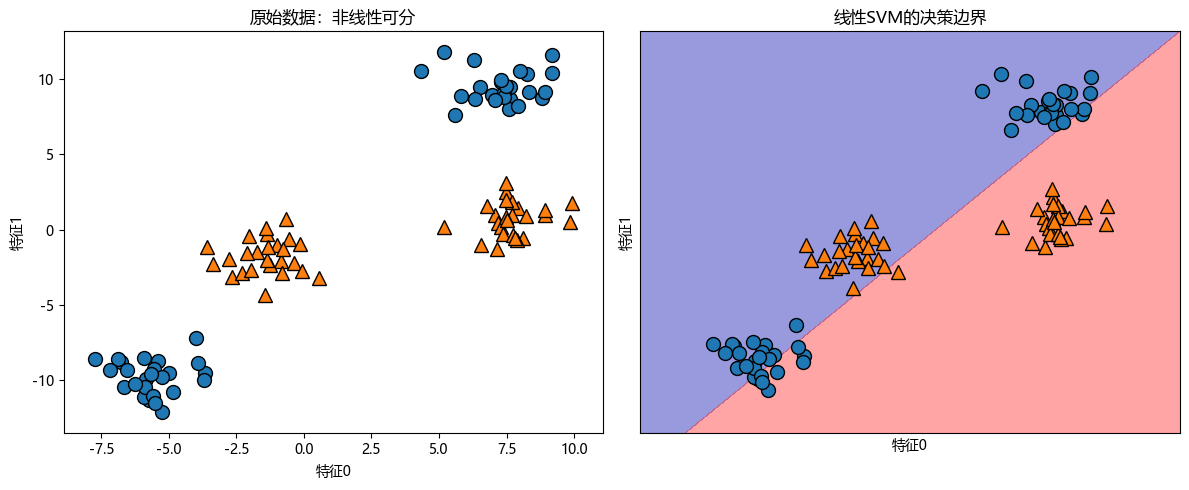

观察：线性SVM无法用一条直线分开这两个类别!


In [2]:
X,y = make_blobs(centers=4,random_state=8)
y=y%2

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
mglearn.discrete_scatter(X[:,0],X[:,1],y)
plt.xlabel("特征0")
plt.ylabel("特征1")
plt.title("原始数据：非线性可分")

from sklearn.svm import LinearSVC
linear_svm = LinearSVC(dual='auto',random_state=42)
linear_svm.fit(X,y)

plt.subplot(1,2,2)
mglearn.plots.plot_2d_separator(linear_svm,X,fill=True,alpha=0.4)
mglearn.discrete_scatter(X[:,0],X[:,1],y)
plt.xlabel("特征0")
plt.ylabel("特征1")
plt.title("线性SVM的决策边界")

plt.tight_layout()
plt.show()

print("观察：线性SVM无法用一条直线分开这两个类别!")

添加新特征后的数据
原始数据形状：(100, 2)
新数据形状：(100, 3)


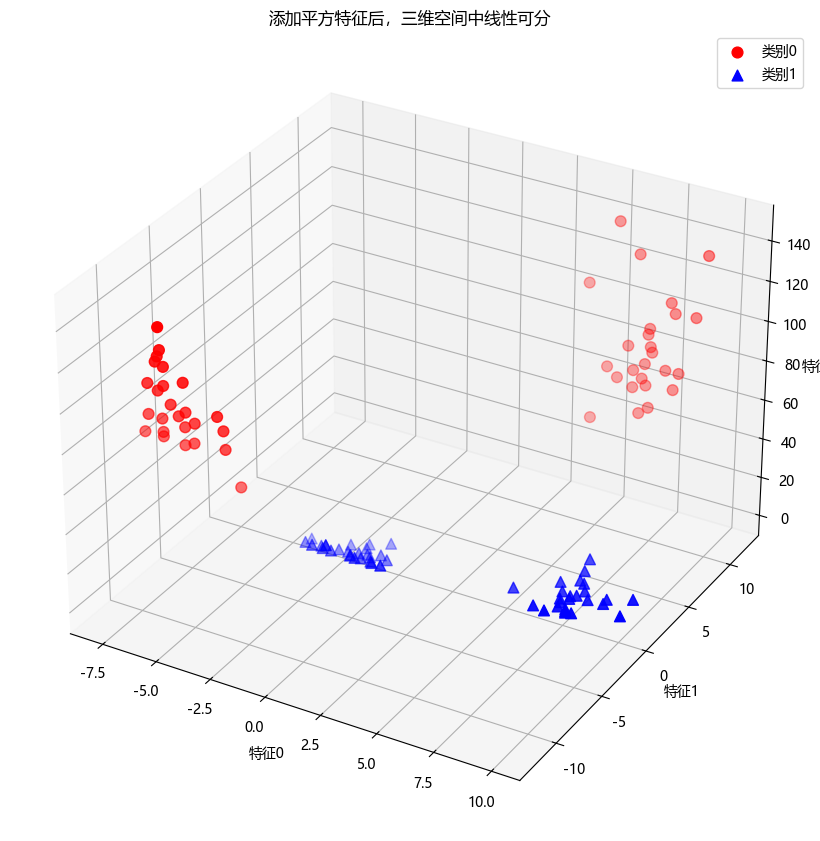

In [5]:
X_new = np.hstack([X,X[:,1:]**2])

print("="*50)
print("添加新特征后的数据")
print("="*50)
print(f"原始数据形状：{X.shape}")
print(f"新数据形状：{X_new.shape}")

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = Axes3D(fig,auto_add_to_figure=False)
fig.add_axes(ax)

mask = y ==0
ax.scatter(X_new[mask,0],X_new[mask,1],X_new[mask,2],
           c='red',s=60,label='类别0')

mask = y ==1
ax.scatter(X_new[mask,0],X_new[mask,1],X_new[mask,2],c='blue',marker='^',
           s=60,label='类别1')

ax.set_xlabel("特征0")
ax.set_ylabel("特征1")
ax.set_zlabel("特征1²")
ax.set_title("添加平方特征后，三维空间中线性可分")
plt.legend()
plt.show()

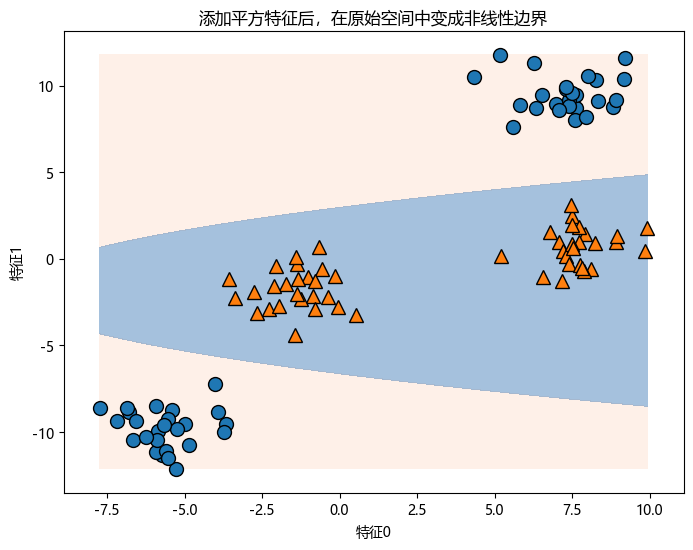

观察:在原始空间中，决策边界变成了椭圆!


In [6]:
linear_svm_3d = LinearSVC(dual='auto',random_state=42)
linear_svm_3d.fit(X_new,y)

plt.figure(figsize=(8,6))

xx,yy = np.meshgrid(np.linspace(X[:,0].min(),X[:,0].max(),100),
                    np.linspace(X[:,1].min(),X[:,1].max(),100))

ZZ =yy **2
dec = linear_svm_3d.decision_function(np.c_[xx.ravel(),yy.ravel(),ZZ.ravel()])
dec = dec.reshape(xx.shape)

plt.contourf(xx,yy,dec,levels=[dec.min(),0,dec.max()],alpha=0.4,cmap='RdBu')
mglearn.discrete_scatter(X[:,0],X[:,1],y)
plt.xlabel("特征0")
plt.ylabel("特征1")
plt.title("添加平方特征后，在原始空间中变成非线性边界")
plt.show()

print("观察:在原始空间中，决策边界变成了椭圆!")

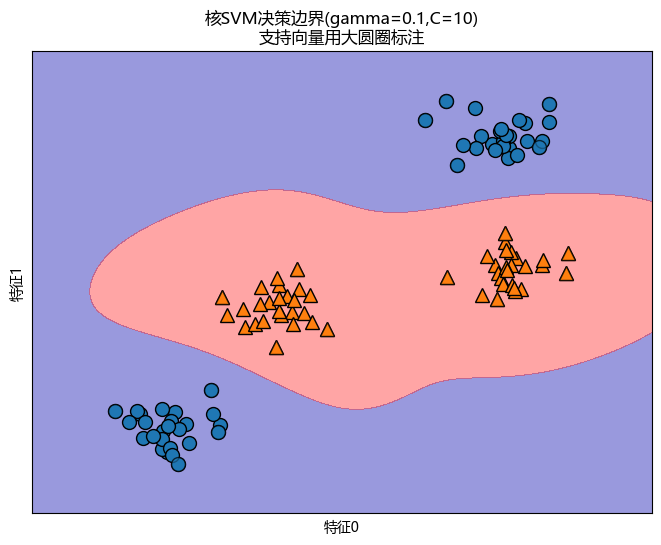

支持向量数量:18


In [13]:
svm = SVC(kernel='rbf',gamma=0.1,C=10)
svm.fit(X,y)

plt.figure(figsize=(8,6))
mglearn.plots.plot_2d_separator(svm,X,fill=True,alpha=0.4)
mglearn.discrete_scatter(X[:,0],X[:,1],y)

sv = svm.support_vectors_
sv_labels = svm.dual_coef_.ravel()>0
mglearn.discrete_scatter(sv[:,0],sv[:,1],sv_labels,
                         s=10,markeredgewidth=1,alpha=0.7)
plt.xlabel("特征0")
plt.ylabel("特征1")
plt.title(f"核SVM决策边界(gamma=0.1,C=10)\n支持向量用大圆圈标注")
plt.show()

print(f"支持向量数量:{len(sv)}")


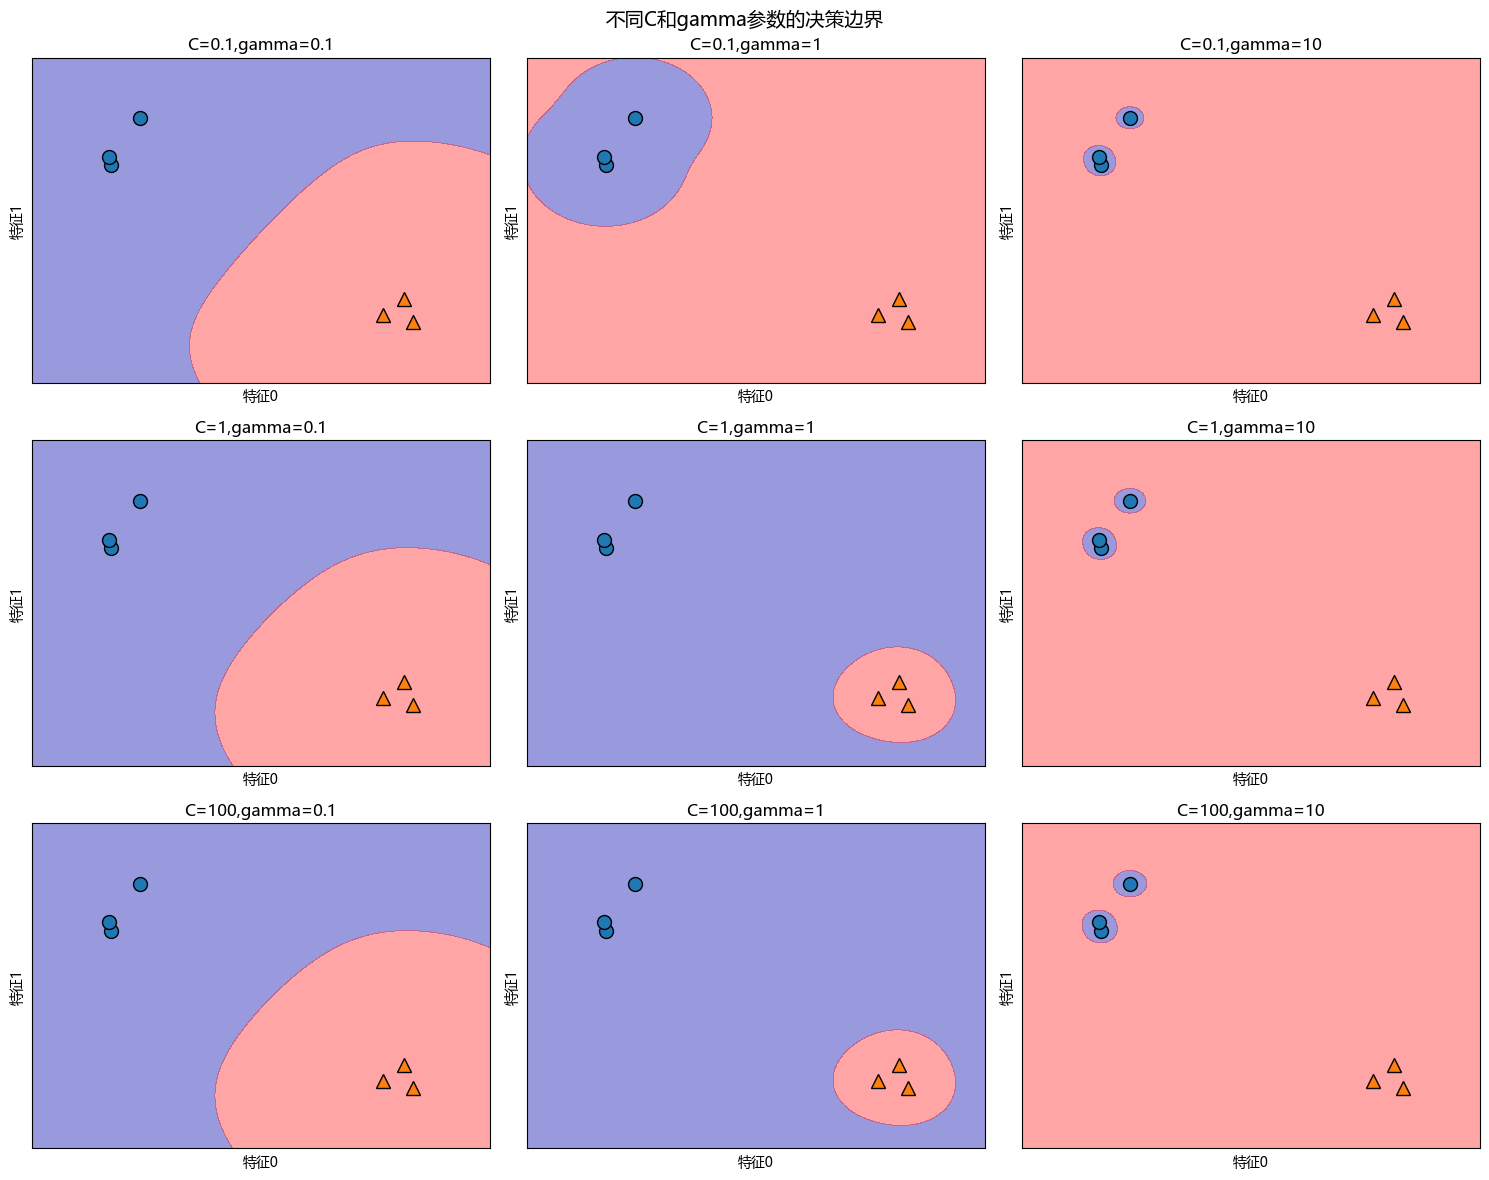

参数观察结论
gamma小（左列）：决策边界平滑，模型简单
gamma大(右列)：决策边界负责，容易过拟合
C小(上行):正则化强，模型简单
C大(下行):正则化弱,模型复杂


In [20]:
X_simple,y_simple = make_blobs(centers=2,random_state=42)
X_simple = X_simple[:6]
y_simple = y_simple[:6]

fig,axes = plt.subplots(3,3,figsize=(15,12))

gamma_values = [0.1,1,10]
C_values = [0.1,1,100]

for i ,C in enumerate(C_values):
    for j,gamma in enumerate(gamma_values):
        svm = SVC(kernel='rbf',gamma=gamma,C=C)
        svm.fit(X_simple,y_simple)

        mglearn.plots.plot_2d_separator(svm,X_simple,fill=True,alpha=0.4,
        ax=axes[i,j])
        mglearn.discrete_scatter(X_simple[:,0],X_simple[:,1],y_simple,ax=axes[i,j])
        axes[i,j].set_title(f"C={C},gamma={gamma}")
        axes[i,j].set_xlabel("特征0")
        axes[i,j].set_ylabel("特征1")

plt.suptitle("不同C和gamma参数的决策边界",fontsize=14)
plt.tight_layout()
plt.show()

print("="*50)
print("参数观察结论")
print("="*50)
print("gamma小（左列）：决策边界平滑，模型简单")
print("gamma大(右列)：决策边界负责，容易过拟合")
print("C小(上行):正则化强，模型简单")
print("C大(下行):正则化弱,模型复杂")

In [22]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

cancer = load_breast_cancer()
X_train,X_test,y_train,y_test = train_test_split(
    cancer.data,cancer.target,random_state=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_default = SVC()
svm_default.fit(X_train_scaled,y_train)

print("="*50)
print("核SVC在乳腺癌数据集上的表现")
print("="*50)
print(f"默认参数（C=1,gamma='scale'）:")
print(f"训练集精度:{svm_default.score(X_train_scaled,y_train):.3f}")
print(f"测试集精度:{svm_default.score(X_test_scaled,y_test):.3f}")

svm_tuned = SVC(C=100,gamma=0.01)
svm_tuned.fit(X_train_scaled,y_train)

print(f"\n调参后(C=100,gamma=0.01):")
print(f"训练集精度:{svm_tuned.score(X_train_scaled,y_train):.3f}")
print(f"测试集精度:{svm_tuned.score(X_test_scaled,y_test):.3f}")

核SVC在乳腺癌数据集上的表现
默认参数（C=1,gamma='scale'）:
训练集精度:0.986
测试集精度:0.965

调参后(C=100,gamma=0.01):
训练集精度:0.993
测试集精度:0.958
